Columns: ('x_um', 'y_um', 'Ex_Vcm', 'Ey_Vcm', 'Emag_Vcm', 'V')
efield_window.csv: 99800 points, x in [15.01, 24.91] um, y in [0.15, 50.00] um
|E| max = 3.85e+05 V/cm at (15.013, 0.397) um
Saved figure as efield_window.png
E_peak(x): mean = 3.849e+05 V/cm, spread = 1.04e+03 V/cm (0.27%)


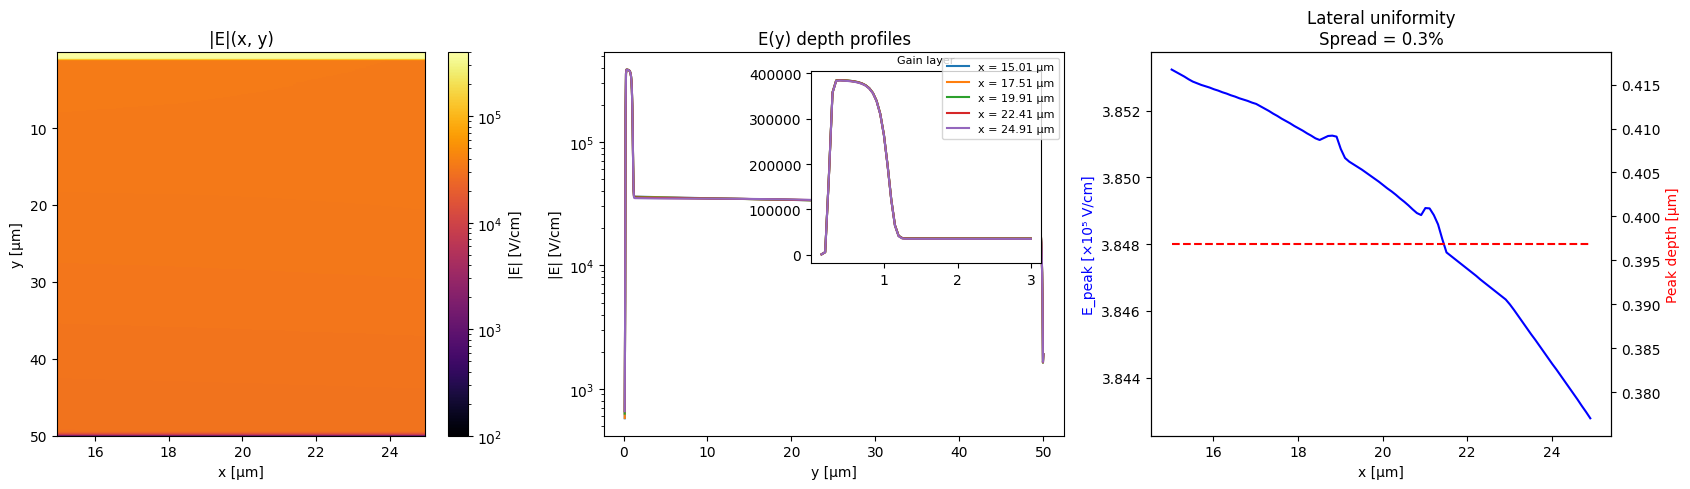

Minimum E = 5.76e+02 V/cm
Maximum E = 3.85e+05 V/cm
Median  E = 3.34e+04 V/cm


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fname = "efield_window.csv"
d = np.genfromtxt(fname, delimiter=",", names=True)
print("Columns:", d.dtype.names)

x = d["x_um"]
y = d["y_um"]
e = d["Emag_Vcm"]

print(
    f"{fname}: {len(x)} points, "
    f"x in [{x.min():.2f}, {x.max():.2f}] um, "
    f"y in [{y.min():.2f}, {y.max():.2f}] um"
)

print(
    f"|E| max = {e.max():.3g} V/cm at "
    f"({x[e.argmax()]:.3f}, {y[e.argmax()]:.3f}) um"
)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ax = axes[0]
xs = np.unique(x)
ys = np.unique(y)
grid = np.full((len(ys), len(xs)), np.nan)
ix = np.searchsorted(xs, x)
iy = np.searchsorted(ys, y)

grid[iy, ix] = e

from matplotlib.colors import LogNorm

# Avoid log(0)
grid_plot = np.clip(grid, 1e2, 4e5)

pc = ax.pcolormesh(
    xs,
    ys,
    grid_plot,
    norm=LogNorm(vmin=1e2, vmax=4e5),
    cmap="inferno",
    shading="auto"
)

cbar = fig.colorbar(pc, ax=ax)
cbar.set_label("|E| [V/cm]")

ax.invert_yaxis()
ax.set_xlabel("x [µm]")
ax.set_ylabel("y [µm]")
ax.set_title("|E|(x, y)")


ax = axes[1]

for xq in np.linspace(xs.min(), xs.max(), 5):
    xc = xs[np.argmin(np.abs(xs - xq))]
    m = (x == xc)
    order = np.argsort(y[m])

    ax.plot(
        y[m][order],
        e[m][order],
        label=f"x = {xc:.2f} µm"
    )

ax.set_yscale("log")
ax.set_xlabel("y [µm]")
ax.set_ylabel("|E| [V/cm]")
ax.set_title("E(y) depth profiles")
ax.legend(fontsize=8)

axin = ax.inset_axes([0.45, 0.45, 0.5, 0.5])

for xq in np.linspace(xs.min(), xs.max(), 5):
    xc = xs[np.argmin(np.abs(xs - xq))]
    m = (x == xc) & (y < 3.0)
    order = np.argsort(y[m])

    axin.plot(
        y[m][order],
        e[m][order]
    )

axin.set_title("Gain layer", fontsize=8)

ax = axes[2]

epk = np.array([
    np.nanmax(grid[:, i])
    for i in range(len(xs))
])

ypk = np.array([
    ys[np.nanargmax(grid[:, i])]
    for i in range(len(xs))
])

ax.plot(
    xs,
    epk / 1e5,
    "b-",
    label="E_peak"
)

ax.set_xlabel("x [µm]")
ax.set_ylabel("E_peak [×10⁵ V/cm]", color="b")

spread = 100 * (epk.max() - epk.min()) / epk.mean()

ax.set_title(f"Lateral uniformity\nSpread = {spread:.1f}%")

ax2 = ax.twinx()

ax2.plot(
    xs,
    ypk,
    "r--",
    label="y_peak"
)

ax2.set_ylabel("Peak depth [µm]", color="r")

plt.tight_layout()

plt.savefig("efield_window.png", dpi=140)

print("Saved figure as efield_window.png")

print(
    f"E_peak(x): mean = {epk.mean():.4g} V/cm, "
    f"spread = {epk.max() - epk.min():.3g} V/cm "
    f"({spread:.2f}%)"
)

# Display in the notebook
plt.show()
print(f"Minimum E = {np.nanmin(grid):.2e} V/cm")
print(f"Maximum E = {np.nanmax(grid):.2e} V/cm")
print(f"Median  E = {np.nanmedian(grid):.2e} V/cm")